<a href="https://colab.research.google.com/github/Beet5codes/lsamp_pheno_snowmelt/blob/main/My_copy_gee_ndvi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connect to GEE account

important step here includes the initialization, when you run this it will create a pop up that asks for permission, click accept.

In [ ]:
import ee
import geemap

# authenticate
ee.Authenticate()

# Initialize Earth Engine
ee.Initialize(project='sequoia-project-462618')

# Get regions of interest and load data

Set points with a buffer area around lon-lat and save as a feature collection.  

Get MODIS NDVI data for the year selected.

In [ ]:
buff = 500

# FeatureCollection from a list of features
list_of_features = [
    ee.Feature(ee.Geometry.Point(-118.716, 36.334).buffer(buff), {'key': 'Garfield'}),
    ee.Feature(ee.Geometry.Point(-118.842, 36.631).buffer(buff), {'key': 'Muir'})
]
region_fc = ee.FeatureCollection(list_of_features)

# set start and end date
year = 2001
startdate = ee.Date.fromYMD(year, 1, 1)
enddate = startdate.advance(1, 'year')

# Load MODIS NDVI dataset
dataset = (ee.ImageCollection('MODIS/MOD09GA_006_NDVI')
           .select('NDVI')
           .filter(ee.Filter.date(startdate, enddate)))


# Reduce region to get time series

For each image, which represent a date, select the mean NDVI for our two regions, then flatten time series.

Saved as a pandas data frame `df`


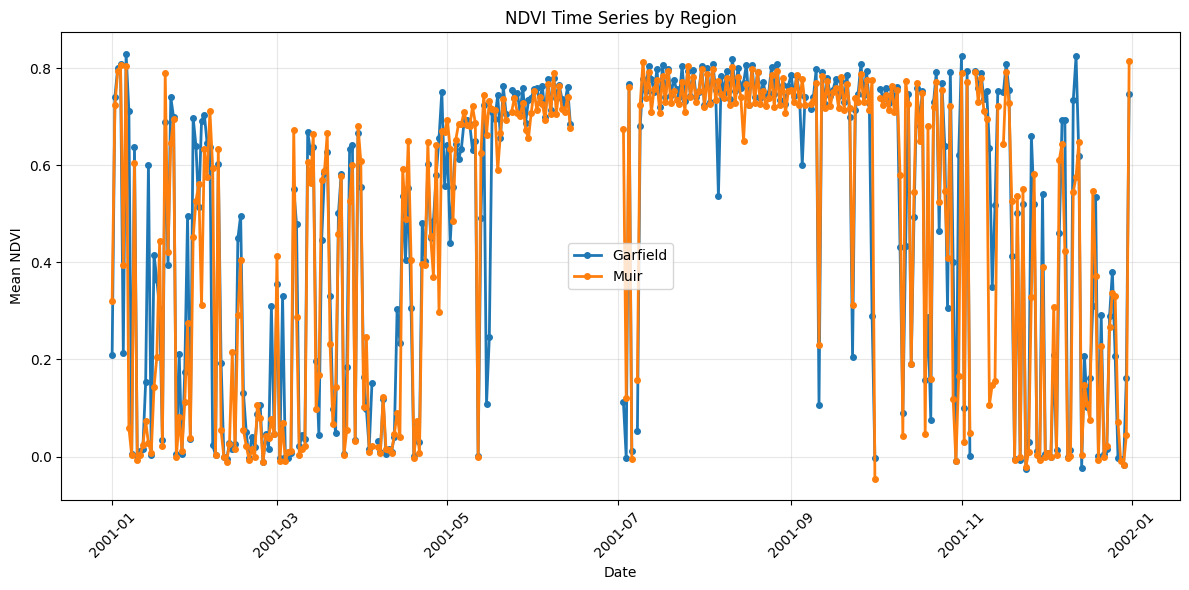


Data Summary:
          count      mean       std       min       max
key                                                    
Garfield    340  0.480805  0.306876 -0.025077  0.830310
Muir        340  0.468708  0.309320 -0.045798  0.815823


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

# Function to reduce to regions for each image
def get_time_series(image):
    date = image.date().format('YYYY-MM-dd')

    # Stats for groves
    stats = image.reduceRegions(
        collection=region_fc,
        scale=500,
        reducer=ee.Reducer.mean()
    )

    def add_date_to_feature(feature):
        return (feature.set('date', date)
                      .set('system:time_start', image.get('system:time_start')))

    return stats.map(add_date_to_feature)

# Map the function over the collection
time_series = dataset.map(get_time_series).flatten()


# Convert data
df = ee.data.computeFeatures({
    'expression': time_series,
    'fileFormat': 'PANDAS_DATAFRAME'
})

# Convert date strings to datetime
df['date'] = pd.to_datetime(df['date'])

# Create the plot
plt.figure(figsize=(12, 6))

# Plot each region separately
for key in df['key'].unique():
    subset = df[df['key'] == key]
    plt.plot(subset['date'], subset['mean'],
            marker='o', label=key, linewidth=2, markersize=4)

plt.xlabel('Date')
plt.ylabel('Mean NDVI')
plt.title('NDVI Time Series by Region')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print some statistics
print("\nData Summary:")
print(df.groupby('key')['mean'].agg(['count', 'mean', 'std', 'min', 'max']))


# Smoothing time series

First, NA values are filled by interpolation

Testing different methods for smoothing:
- moving average
- loess
- savitzky-golay

348
df 348
348
df 348


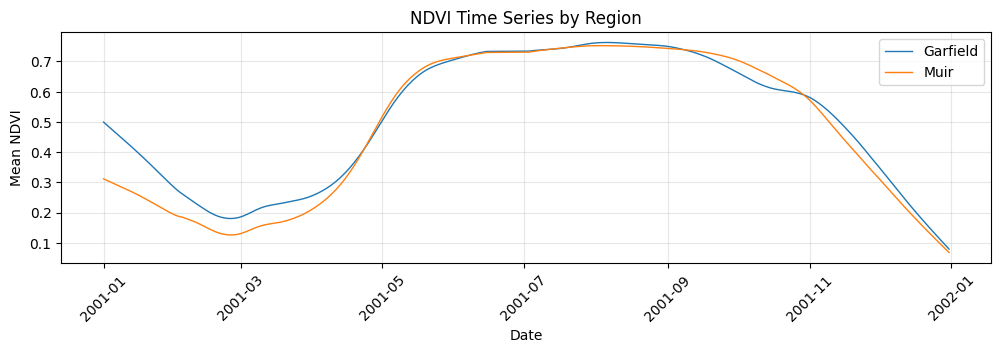

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.interpolate import UnivariateSpline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
from statsmodels.nonparametric.smoothers_lowess import lowess

def smooth_ndvi_timeseries(df, method='savgol'):
    """
    Smooth NDVI time series data
    df should have 'date' and 'mean' columns
    """
    df_filled = df.interpolate(method='linear')

    if method == 'savgol':
        # Good for preserving NDVI peaks/valleys
        window = min(31, len(df_filled) // 3)  # Adaptive window size
        if window % 2 == 0:
            window += 1  # Must be odd
        print(window)
        df_filled['smoothed'] = signal.savgol_filter(df_filled['mean'], window, 1, mode='nearest')

    elif method == 'moving_average':
        # Simple moving average
        df_filled['smoothed'] = df_filled['mean'].rolling(window=30, center=True).mean()

    elif method == 'lowess':
        # Apply LOWESS smoothing
        smoothed = lowess(df_filled['mean'], np.arange(len(df_filled['mean'])), frac=0.2)
        print(len(smoothed))
        print("df",len(df_filled))
        df_filled['smoothed'] = smoothed[:, 1]


    return df_filled

plt.figure(figsize=(12, 3))

# for loop goes through the same steps for both regions
for key in df['key'].unique():
    subset = df[df['key'] == key]
    smooth_df = smooth_ndvi_timeseries(subset, method="lowess")
    plt.plot(smooth_df['date'], smooth_df['smoothed'],
            label=key, linewidth=1, markersize=4)


# Plot each region separatel
plt.xlabel('Date')
plt.ylabel('Mean NDVI')
plt.title('NDVI Time Series by Region')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
#plt.tight_layout()
plt.show()

In [ ]:
from datetime import datetime

for key in df['key'].unique():
    subset = df[df['key'] == key]
    ndvi = subset['mean']
    na_percent = (ndvi.isna().sum()/len(ndvi))*100
    print("percent of NA:", key, na_percent)

df['year'] = df['date'].dt.year

df.head()


percent of NA: Garfield 2.2988505747126435
percent of NA: Muir 2.2988505747126435


,geo,date,key,mean,year
0,"{'type': 'Polygon', 'coordinates': [[[-118.721...",2001-01-01,Garfield,0.208483,2001
1,"{'type': 'Polygon', 'coordinates': [[[-118.847...",2001-01-01,Muir,0.320781,2001
2,"{'type': 'Polygon', 'coordinates': [[[-118.721...",2001-01-02,Garfield,0.741263,2001
3,"{'type': 'Polygon', 'coordinates': [[[-118.847...",2001-01-02,Muir,0.724267,2001
4,"{'type': 'Polygon', 'coordinates': [[[-118.721...",2001-01-03,Garfield,0.800802,2001


# Plot to compare smoothed and get annual metrics

- Using lowess filter
- filling in NAs may change from year to year, if there are too many NAs, use rolling mean with interpolation

From smoothed values getting max value and day of year when max occurrs.

Next steps:
- normalize time series
- get transition dates of percentages

Annual metrics to get

- 50% transition day / value
- 10% transition day / value
- max / day of max

696
df 696


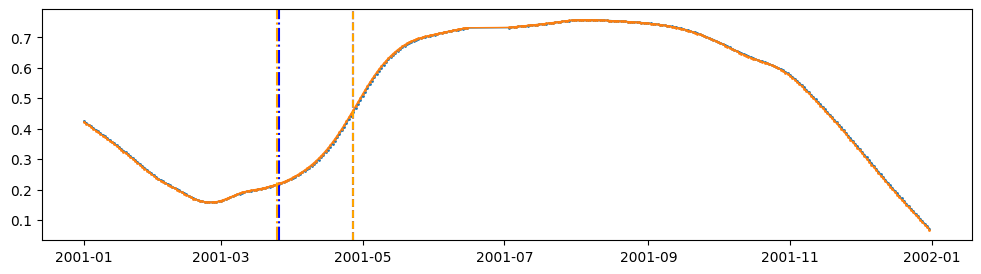

In [ ]:

# set up plot
labels = ['Garfield','Muir']
colors = ['blue','orange']
# Create color mapping
color_map = dict(zip(labels, colors))

def get_annual_metrics(data, spring_threshold=datetime(year, 3, 1)):

  # get max for the year
  max_ndvi = data['smoothed'].max()

  # date of max
  date_max = data.query(f'smoothed=={max_ndvi}')['date'].iloc[0]

  if date_max < spring_threshold:
    filt_date = data.query(f'date>"{spring_threshold}"')
    max_ndvi = filt_date['smoothed'].max()
    print("max_ndvi:", max_ndvi)
    date_max = data.query(f'smoothed=={max_ndvi}')['date'].iloc[0]
    print("date max:", date_max)

  # normalize
  greenup = data.query('date <= @date_max')
  min_ndvi = greenup['smoothed'].min()
  greenup['smooth_norm'] = (greenup['smoothed']-min_ndvi)/(max_ndvi-min_ndvi)

  # date of min
  date_min = greenup.query(f'smoothed=={min_ndvi}')['date'].iloc[0]

  # time period to get transition dates from
  greenup = greenup.query(f'date>=@date_min')
  #print(greenup)

  # bud burst
  ndvi_10 =  (greenup['smooth_norm'] - 0.10).abs().idxmin()

  #print(greenup.loc[ndvi_10])
  date_10 = greenup.loc[ndvi_10,'date']

  # spring transition
  ndvi_50 = (greenup['smooth_norm'] - 0.50).abs().idxmin()
  #print(greenup.loc[ndvi_50])
  date_50 = greenup.loc[ndvi_50,'date']

  plt.plot(data['date'], data['smoothed'],
          marker='o', label=key, linewidth=1, markersize=1)
  plt.axvline(x=date_10, linestyle="-.", label="10%", color=color_map[key])
  plt.axvline(x=date_50, linestyle="--", label="50%", color=color_map[key])

  df = {
      'max_ndvi': [max_ndvi],
      'date_max_ndvi': [date_max],
      'min_spring_ndvi': [min_ndvi],
      'date_min_spring_ndvi':[date_min],
      'ndvi_10': [greenup.loc[ndvi_10,'smoothed']],
      'date_ndvi_10': [date_10],
      'ndvi_50': [greenup.loc[ndvi_50,'smoothed']],
      'date_ndvi_50': date_50,
      'site': [key]
  }
  amdf = pd.DataFrame(df)
  return amdf

smooth_results = []
ann_results = []


plt.figure(figsize=(12, 3))
# fill and smooth NDVI
smooth_df = smooth_ndvi_timeseries(df, method="lowess")

# for loop through region
for key in smooth_df['key'].unique():
  for i in smooth_df['year'].unique():

    filt = smooth_df[smooth_df['year']==i]
    # subset by ROI
    subset = filt[filt['key'] == key]
    #print(len(subset))
    # smooth again
    subset['first_smooth'] = subset['smoothed']

    #lo = lowess(subset['smoothed'], np.arange(len(subset['smoothed'])), frac=0.3)
    #print(len(lo))
    #subset['smoothed'] = lo[:, 1]

    # get annual metrics
    ann_data = get_annual_metrics(subset, spring_threshold=datetime(year,3,1))

    # Append to lists
    smooth_results.append(subset)
    ann_results.append(ann_data)

# Combine all results
final_smooth_df = pd.concat(smooth_results, ignore_index=True)
final_annual_df = pd.concat(ann_results, ignore_index=True)

In [ ]:
final_annual_df.head()

,max_ndvi,date_max_ndvi,min_spring_ndvi,date_min_spring_ndvi,ndvi_10,date_ndvi_10,ndvi_50,date_ndvi_50,site
0,0.733339,2012-07-26,0.421552,2012-03-16,0.453166,2012-04-07,0.577273,2012-05-09,Garfield
1,0.712531,2013-08-31,0.461983,2013-01-07,0.486684,2013-02-03,0.587528,2013-04-27,Garfield
2,0.733339,2012-07-25,0.421559,2012-03-16,0.451838,2012-04-06,0.579644,2012-05-09,Muir
3,0.712531,2013-08-31,0.461973,2013-01-07,0.487387,2013-02-03,0.586505,2013-04-26,Muir


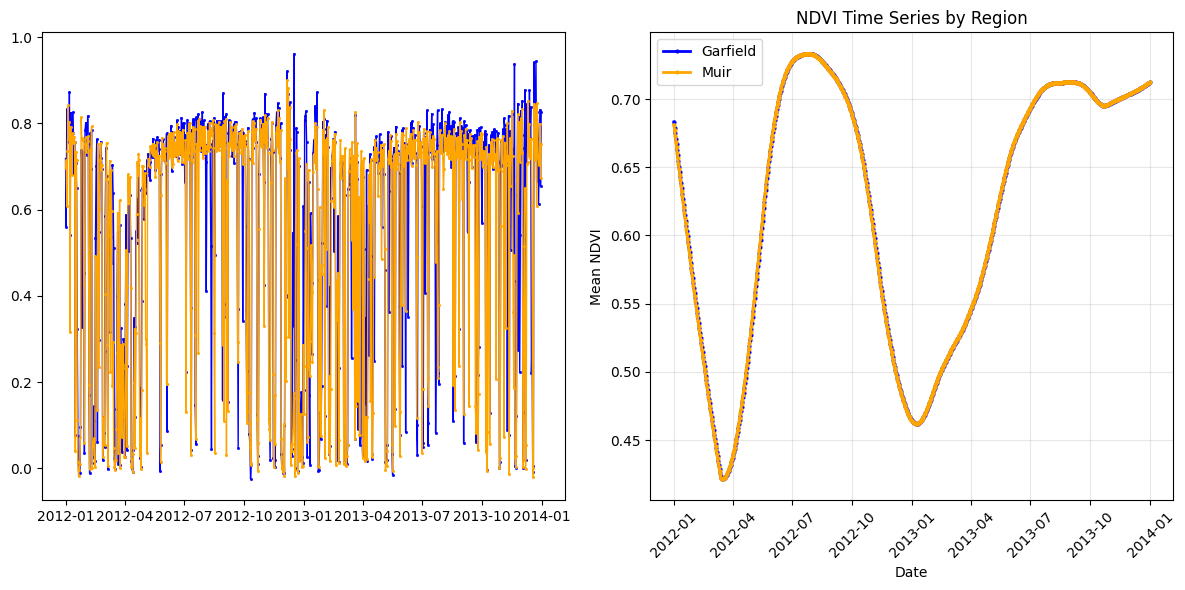

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot each group separately
for key, subset in final_smooth_df.groupby('key'):
    color = color_map[key]

    subset2 = final_annual_df.query(f'site=="{key}"')
    line1 = axes[0].plot(subset['date'], subset['mean'],
                        marker='s', label=key, linewidth=1, markersize=1,
                        color=color)
    line2 = axes[1].plot(subset['date'], subset['smoothed'],
                        marker='o', label=key, linewidth=2, markersize=2,
                        color=color)
    #axes[1].axvline(x=subset2['date_max_ndvi'], linestyle="--", color=color_map[key], label=key)



# Plot each region separatel
plt.xlabel('Date')
plt.ylabel('Mean NDVI')
plt.title('NDVI Time Series by Region')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Loop through years

In [ ]:
# set range of years to loop through
tsyears = list(range(2001, 2022))

# create empty data frames for saving data
daily_res = []
ann_res = []

for year in tsyears:

  # create empty data frames for inside for loop gathering keys
  smooth_results = []
  ann_results = []

  # set start and end date
  startdate = ee.Date.fromYMD(year, 1, 1)
  enddate = startdate.advance(1, 'year')

  # Load MODIS NDVI dataset
  dataset = (ee.ImageCollection('MODIS/MOD09GA_006_NDVI')
            .select('NDVI')
            .filter(ee.Filter.date(startdate, enddate)))

  # Map the function over the collection
  time_series = dataset.map(get_time_series).flatten()

  # Convert data
  df = ee_to_pandas(time_series)

  # Convert date strings to datetime
  df['date'] = pd.to_datetime(df['date'])

  for key in df['key'].unique():
    # subset by ROI
    subset = df[df['key'] == key]
    # fill and smooth NDVI
    smooth_df = smooth_ndvi_with_na(subset, frac=0.2)

    # set spring threshold for checking max
    st = datetime(year, 3,1)

    # get annual metrics
    ann_data = get_annual_metrics(smooth_df, spring_threshold=st)

    # Append to lists
    smooth_results.append(smooth_df)
    ann_results.append(ann_data)

  # Combine all results
  smooth_df = pd.concat(smooth_results, ignore_index=True)
  annual_df = pd.concat(ann_results, ignore_index=True)

  annual_df['year'] = year

  # append to multiyear df
  daily_res.append(smooth_df)
  ann_res.append(annual_df)

  final_daily_res = pd.concat(daily_res, ignore_index=True)
  final_ann_res = pd.concat(ann_res, ignore_index=True)


NameError: name 'ee_to_pandas' is not defined

In [ ]:
final_smooth_df.head()
#print(final_ann_res)

final_smooth_df.to_csv("daily_ndvi_smoothed1213.csv", index=False)
final_annual_df.to_csv("ann_ndvi_metrics1213.csv", index=False)


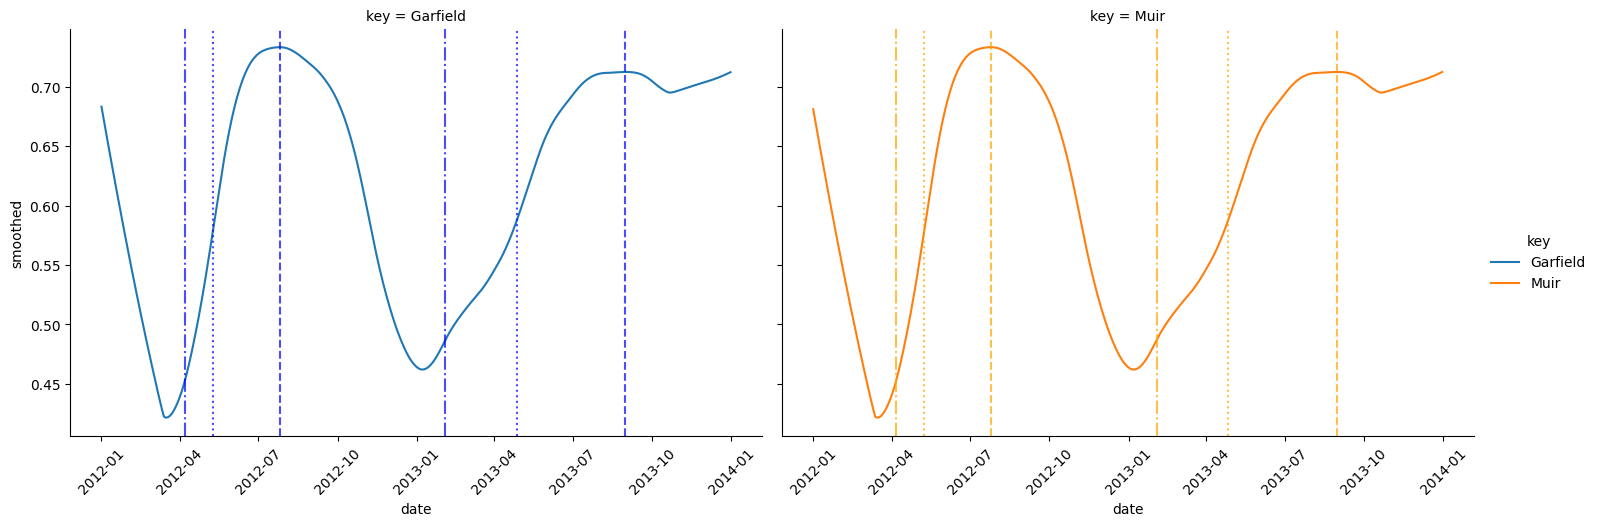

In [ ]:
import seaborn as sns
# Create the plot

g = sns.relplot(data=final_smooth_df, x='date', y='smoothed', kind='line',
                col='key', hue='key', aspect=1.5, height=5)

# Define which columns contain dates for vertical lines
date_columns = ['date_ndvi_10', 'date_max_ndvi', 'date_ndvi_50']
line_styles = ['-.',  '--', ':']

for (key, ax) in g.axes_dict.items():
    subset = final_annual_df[final_annual_df['site'] == key]

    # Loop through each ROW in the subset
    for _, row in subset.iterrows():
        # Loop through each DATE COLUMN
        for date_col, style in zip(date_columns, line_styles):
            if date_col in row and pd.notna(row[date_col]):
                ax.axvline(x=row[date_col], linestyle=style,
                          color=color_map[key], alpha=0.7)

    # Rotate x-axis labels to 45 degrees
    ax.tick_params(axis='x', rotation=45)


In [ ]:
subset = final_annual_df[final_annual_df['site'] == "Muir"]
subset.head()

,max_ndvi,date_max_ndvi,min_spring_ndvi,date_min_spring_ndvi,ndvi_10,date_ndvi_10,ndvi_50,date_ndvi_50,site
2,0.733339,2012-07-25,0.421559,2012-03-16,0.451838,2012-04-06,0.579644,2012-05-09,Muir
3,0.712531,2013-08-31,0.461973,2013-01-07,0.487387,2013-02-03,0.586505,2013-04-26,Muir


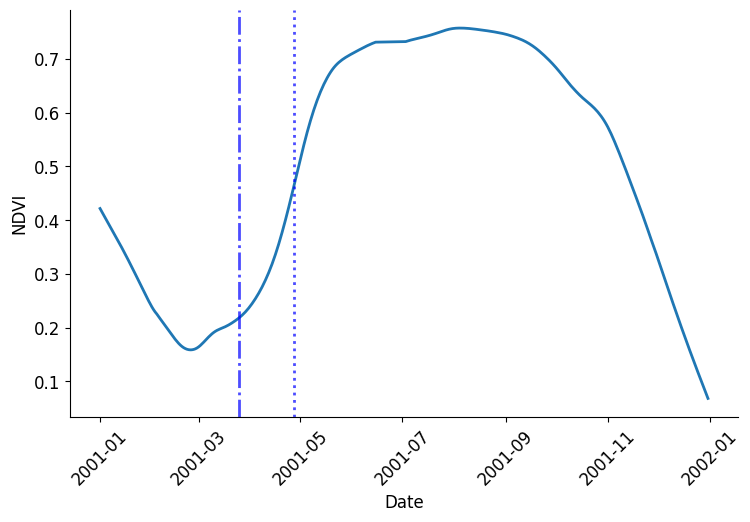

In [ ]:
import seaborn as sns
# Create the plot

muir = final_smooth_df[final_smooth_df['key']=="Muir"]

g = sns.relplot(data=muir, x='date', y='smoothed', kind='line',
                col='key', hue='key', aspect=1.5, height=5, legend=False,
                linewidth=2)

# Define which columns contain dates for vertical lines
date_columns = ['date_ndvi_10', 'date_ndvi_50']
line_styles = ['-.',  ':']

subset = final_annual_df[final_annual_df['site'] == "Muir"]

# Get the correct axis reference
for key, ax in g.axes_dict.items():
    # Loop through each ROW in the subset
    for _, row in subset.iterrows():
        # Loop through each DATE COLUMN
        for date_col, style in zip(date_columns, line_styles):
            if date_col in row and pd.notna(row[date_col]):
                ax.axvline(x=row[date_col], linestyle=style,
                          color='blue', alpha=0.7, linewidth=2)  # Using 'red' as placeholder

    # Rotate x-axis labels to 45 degrees
    ax.tick_params(axis='x', rotation=45, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # Remove title and set y-axis label
    ax.set_title('')
    ax.set_ylabel('NDVI', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
